# Ekstraksi Fitur Musik dan Exploratory Data Analysis (EDA)

Notebook ini mengekstrak fitur audio dari file musik (.wav) termasuk:
- **MFCC** (Mel-Frequency Cepstral Coefficients)
- **Mel Spectrogram** 
- **Chroma Features**

Kemudian melakukan EDA untuk menganalisis karakteristik audio.

## 1. Import Required Libraries

In [1]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Semua library berhasil diimport")

✓ Semua library berhasil diimport


## 2. Load dan Baca Audio Files

In [2]:
# Define paths
data_dir = Path('data/genres_original')
audio_files = []
genres = []

# Load semua audio files dari setiap genre
print("Loading audio files...")
for genre_folder in sorted(data_dir.iterdir()):
    if genre_folder.is_dir():
        genre_name = genre_folder.name
        for audio_file in sorted(genre_folder.glob('*.wav')):
            audio_files.append(str(audio_file))
            genres.append(genre_name)

print(f"✓ Total audio files ditemukan: {len(audio_files)}")
print(f"✓ Genres: {set(genres)}")

# Load sample audio untuk contoh
sample_file = audio_files[0]
y, sr = librosa.load(sample_file, sr=None)

print(f"\n✓ Sample file: {sample_file}")
print(f"✓ Sampling rate: {sr} Hz")
print(f"✓ Duration: {len(y) / sr:.2f} seconds")

Loading audio files...
✓ Total audio files ditemukan: 1000
✓ Genres: {'reggae', 'jazz', 'blues', 'metal', 'classical', 'rock', 'disco', 'hiphop', 'pop', 'country'}

✓ Sample file: data\genres_original\blues\blues.00000.wav
✓ Sampling rate: 22050 Hz
✓ Duration: 30.01 seconds


## 3. Extract MFCC Features

In [3]:
# Extract MFCC features dari semua audio files
print("Extracting MFCC features...")

mfcc_data = []
n_mfcc = 13

for audio_file in tqdm(audio_files):
    try:
        y, sr = librosa.load(audio_file, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        
        # Calculate mean dan variance untuk setiap MFCC coefficient
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_var = np.var(mfcc, axis=1)
        
        # Combine mean dan variance
        mfcc_features = np.concatenate([mfcc_mean, mfcc_var])
        mfcc_data.append(mfcc_features)
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")

# Convert to DataFrame
mfcc_columns = [f'mfcc_{i}_mean' for i in range(n_mfcc)] + [f'mfcc_{i}_var' for i in range(n_mfcc)]
mfcc_df = pd.DataFrame(mfcc_data, columns=mfcc_columns)
mfcc_df['genre'] = genres[:len(mfcc_df)]
mfcc_df['filename'] = audio_files[:len(mfcc_df)]

print(f"✓ MFCC features extracted: {mfcc_df.shape}")
print(f"✓ Features per file: {len(mfcc_columns)}")
print("\nMFCC DataFrame sample:")
print(mfcc_df.head())

Extracting MFCC features...


 56%|█████▌    | 559/1000 [00:30<00:19, 22.42it/s]

Error processing data\genres_original\jazz\jazz.00054.wav: 


100%|██████████| 1000/1000 [00:54<00:00, 18.39it/s]

✓ MFCC features extracted: (999, 28)
✓ Features per file: 26

MFCC DataFrame sample:
   mfcc_0_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  \
0  -113.598824   121.570671   -19.162262    42.363937    -6.362266   
1  -207.523834   123.985138     8.947019    35.867149     2.909595   
2   -90.757164   140.440872   -29.084547    31.686693   -13.976547   
3  -199.575134   150.086105     5.663404    26.855278     1.770071   
4  -160.354172   126.209480   -35.581394    22.139256   -32.473549   

   mfcc_5_mean  mfcc_6_mean  mfcc_7_mean  mfcc_8_mean  mfcc_9_mean  ...  \
0    18.621931   -13.699734    15.339802   -12.274304    10.970944  ...   
1    21.519472    -8.556513    23.370676   -10.103608    11.899242  ...   
2    25.753752   -13.664990    11.634442   -11.778322     9.714756  ...   
3    14.232647    -4.827845     9.286853    -0.756120     8.134435  ...   
4    10.850701   -23.350071     0.493249   -11.796538     1.203519  ...   

   mfcc_5_var  mfcc_6_var  mfcc_7_var  mfcc

## 4. Extract Mel Spectrogram Features

In [4]:
# Extract Mel Spectrogram features
print("Extracting Mel Spectrogram features...")

mel_spec_data = []
n_mels = 128

for audio_file in tqdm(audio_files):
    try:
        y, sr = librosa.load(audio_file, sr=None)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Calculate mean dan variance untuk setiap mel bin
        mel_mean = np.mean(mel_spec_db, axis=1)
        mel_var = np.var(mel_spec_db, axis=1)
        mel_max = np.max(mel_spec_db, axis=1)
        mel_min = np.min(mel_spec_db, axis=1)
        
        # Combine all statistics
        mel_features = np.concatenate([mel_mean, mel_var, mel_max, mel_min])
        mel_spec_data.append(mel_features)
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")

# Convert to DataFrame
mel_columns = (
    [f'mel_{i}_mean' for i in range(n_mels)] +
    [f'mel_{i}_var' for i in range(n_mels)] +
    [f'mel_{i}_max' for i in range(n_mels)] +
    [f'mel_{i}_min' for i in range(n_mels)]
)
mel_spec_df = pd.DataFrame(mel_spec_data, columns=mel_columns)
mel_spec_df['genre'] = genres[:len(mel_spec_df)]

print(f"✓ Mel Spectrogram features extracted: {mel_spec_df.shape}")
print(f"✓ Features per file: {len(mel_columns)}")
print("\nMel Spectrogram DataFrame sample:")
print(mel_spec_df.head())

Extracting Mel Spectrogram features...


 56%|█████▌    | 559/1000 [00:15<00:10, 42.65it/s]

Error processing data\genres_original\jazz\jazz.00054.wav: 


100%|██████████| 1000/1000 [00:29<00:00, 33.37it/s]


✓ Mel Spectrogram features extracted: (999, 513)
✓ Features per file: 512

Mel Spectrogram DataFrame sample:
   mel_0_mean  mel_1_mean  mel_2_mean  mel_3_mean  mel_4_mean  mel_5_mean  \
0  -29.813519  -23.186077  -24.534311  -26.720743  -23.712185  -25.006809   
1  -28.858957  -22.102180  -23.432264  -25.042952  -26.778301  -28.338856   
2  -35.261288  -26.644474  -20.737389  -18.634184  -18.921272  -18.785450   
3  -47.773849  -23.090305  -16.448675  -20.967745  -27.110922  -27.829554   
4  -52.370522  -48.174419  -37.481308  -36.687355  -39.170868  -37.355858   

   mel_6_mean  mel_7_mean  mel_8_mean  mel_9_mean  ...  mel_119_min  \
0  -23.837688  -23.695015  -27.261946  -27.953276  ...   -76.888885   
1  -24.452522  -24.936451  -30.864214  -27.323763  ...   -80.000000   
2  -19.452768  -20.248291  -18.770380  -20.948038  ...   -80.000000   
3  -28.170504  -30.667253  -31.241283  -32.035046  ...   -80.000000   
4  -33.787251  -30.658697  -26.548977  -28.522041  ...   -80.000000   

 

## 5. Extract Chroma Features

In [5]:
# Extract Chroma features
print("Extracting Chroma features...")

chroma_data = []
n_chroma = 12  # 12 pitch classes

for audio_file in tqdm(audio_files):
    try:
        y, sr = librosa.load(audio_file, sr=None)
        
        # Extract multiple chroma features
        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
        chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)
        
        # Calculate statistics for each chroma
        chroma_stft_mean = np.mean(chroma_stft, axis=1)
        chroma_stft_var = np.var(chroma_stft, axis=1)
        chroma_cqt_mean = np.mean(chroma_cqt, axis=1)
        chroma_cqt_var = np.var(chroma_cqt, axis=1)
        chroma_cens_mean = np.mean(chroma_cens, axis=1)
        chroma_cens_var = np.var(chroma_cens, axis=1)
        
        # Combine all chroma features
        chroma_features = np.concatenate([
            chroma_stft_mean, chroma_stft_var,
            chroma_cqt_mean, chroma_cqt_var,
            chroma_cens_mean, chroma_cens_var
        ])
        chroma_data.append(chroma_features)
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")

# Convert to DataFrame
chroma_columns = (
    [f'chroma_stft_{i}_mean' for i in range(n_chroma)] +
    [f'chroma_stft_{i}_var' for i in range(n_chroma)] +
    [f'chroma_cqt_{i}_mean' for i in range(n_chroma)] +
    [f'chroma_cqt_{i}_var' for i in range(n_chroma)] +
    [f'chroma_cens_{i}_mean' for i in range(n_chroma)] +
    [f'chroma_cens_{i}_var' for i in range(n_chroma)]
)
chroma_df = pd.DataFrame(chroma_data, columns=chroma_columns)
chroma_df['genre'] = genres[:len(chroma_df)]

print(f"✓ Chroma features extracted: {chroma_df.shape}")
print(f"✓ Features per file: {len(chroma_columns)}")
print("\nChroma DataFrame sample:")
print(chroma_df.head())

Extracting Chroma features...


 55%|█████▌    | 554/1000 [04:04<03:34,  2.08it/s]

Error processing data\genres_original\jazz\jazz.00054.wav: 


100%|██████████| 1000/1000 [07:20<00:00,  2.27it/s]

✓ Chroma features extracted: (999, 73)
✓ Features per file: 72

Chroma DataFrame sample:
   chroma_stft_0_mean  chroma_stft_1_mean  chroma_stft_2_mean  \
0            0.362243            0.367817            0.439834   
1            0.460040            0.350182            0.320807   
2            0.272900            0.195953            0.315165   
3            0.341372            0.408624            0.524319   
4            0.192605            0.317266            0.392022   

   chroma_stft_3_mean  chroma_stft_4_mean  chroma_stft_5_mean  \
0            0.244692            0.247862            0.335616   
1            0.211472            0.200788            0.330794   
2            0.407986            0.546820            0.321699   
3            0.547013            0.657075            0.511524   
4            0.255827            0.192663            0.530221   

   chroma_stft_6_mean  chroma_stft_7_mean  chroma_stft_8_mean  \
0            0.364619            0.435684            0.295986   

## 6. Exploratory Data Analysis (EDA)

In [6]:
# Combine all features into one DataFrame
combined_df = pd.concat([mfcc_df, mel_spec_df.drop('genre', axis=1), chroma_df.drop('genre', axis=1)], axis=1)

print("=" * 80)
print("COMBINED FEATURES DATASET")
print("=" * 80)
print(f"\nShape: {combined_df.shape}")
print(f"Total features: {combined_df.shape[1] - 2}  (excluding genre and filename)")
print(f"\nData types:\n{combined_df.dtypes.value_counts()}")
print(f"\nMissing values:\n{combined_df.isnull().sum().sum()}")

# Genre distribution
print("\n" + "=" * 80)
print("GENRE DISTRIBUTION")
print("=" * 80)
genre_counts = combined_df['genre'].value_counts()
print(genre_counts)

# Basic statistics by genre
print("\n" + "=" * 80)
print("BASIC STATISTICS BY GENRE")
print("=" * 80)

# Select only numeric columns for statistics
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in ['genre']]

stats_by_genre = combined_df.groupby('genre')[feature_cols].describe()
print(f"\nStatistics shape: {stats_by_genre.shape}")
print("\nSample statistics for first genre:")
print(stats_by_genre.iloc[:, :10].head())

COMBINED FEATURES DATASET

Shape: (999, 612)
Total features: 610  (excluding genre and filename)

Data types:
float32    610
str          2
Name: count, dtype: int64

Missing values:
0

GENRE DISTRIBUTION
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock          99
Name: count, dtype: int64

BASIC STATISTICS BY GENRE

Statistics shape: (10, 4880)

Sample statistics for first genre:
          mfcc_0_mean                                                  \
                count        mean         std         min         25%   
genre                                                                   
blues           100.0 -164.608170   84.611015 -350.352631 -228.748325   
classical       100.0 -320.065735  101.386566 -552.158630 -387.634911   
country         100.0 -145.044571   73.011169 -353.091156 -193.858631   
disco           100.0  -93.747826   50.325130 -280.854309 -117

In [7]:
# Analysis MFCC by genre
print("\n" + "=" * 80)
print("MFCC ANALYSIS BY GENRE")
print("=" * 80)

mfcc_mean_cols = [col for col in mfcc_df.columns if 'mean' in col and col != 'genre']
mfcc_analysis = mfcc_df.groupby('genre')[mfcc_mean_cols].mean()
print("\nMean MFCC values by genre:")
print(mfcc_analysis)

# Analysis Mel Spectrogram by genre
print("\n" + "=" * 80)
print("MEL SPECTROGRAM ANALYSIS BY GENRE")
print("=" * 80)

mel_mean_cols = [col for col in mel_spec_df.columns if 'mean' in col and col != 'genre'][:10]  # First 10
mel_analysis = mel_spec_df.groupby('genre')[mel_mean_cols].mean()
print("\nMean Mel Spectrogram values by genre (first 10 bins):")
print(mel_analysis)

# Analysis Chroma by genre
print("\n" + "=" * 80)
print("CHROMA ANALYSIS BY GENRE")
print("=" * 80)

chroma_stft_mean_cols = [col for col in chroma_df.columns if 'chroma_stft' in col and 'mean' in col]
chroma_analysis = chroma_df.groupby('genre')[chroma_stft_mean_cols].mean()
print("\nMean Chroma STFT values by genre:")
print(chroma_analysis)


MFCC ANALYSIS BY GENRE

Mean MFCC values by genre:
           mfcc_0_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  \
genre                                                                        
blues      -164.608185   113.941605    -7.396993    46.615063    -3.650162   
classical  -320.065735   141.251968   -19.675220    23.263657    -2.405138   
country    -145.044571   113.486969    -8.273957    37.649639     1.675958   
disco       -93.747826    84.887352   -10.155089    31.621117    -3.383702   
hiphop     -103.022148    78.961464    -1.322724    38.329784     1.259382   
jazz       -213.979752   113.688797    -5.050123    36.870487    -1.640075   
metal       -63.514751    85.977165   -30.919695    58.174835   -12.927809   
pop         -68.539421    68.460793    12.346236    16.387754     9.714385   
reggae     -162.150711    93.646317    -2.928975    35.087746     4.773979   
rock       -110.286362   101.024696   -15.978290    39.084866    -4.978100   

           

## 7. Visualisasi Audio Features

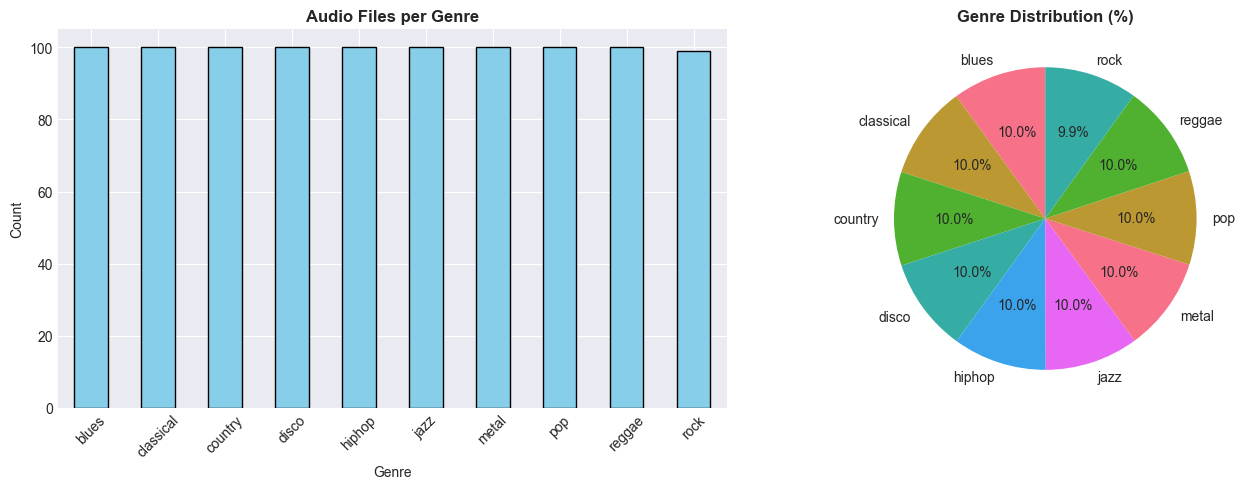

✓ Gambar 1: Genre Distribution


In [8]:
# 1. Genre Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Audio Files per Genre', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

genre_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Genre Distribution (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_genre_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 1: Genre Distribution")

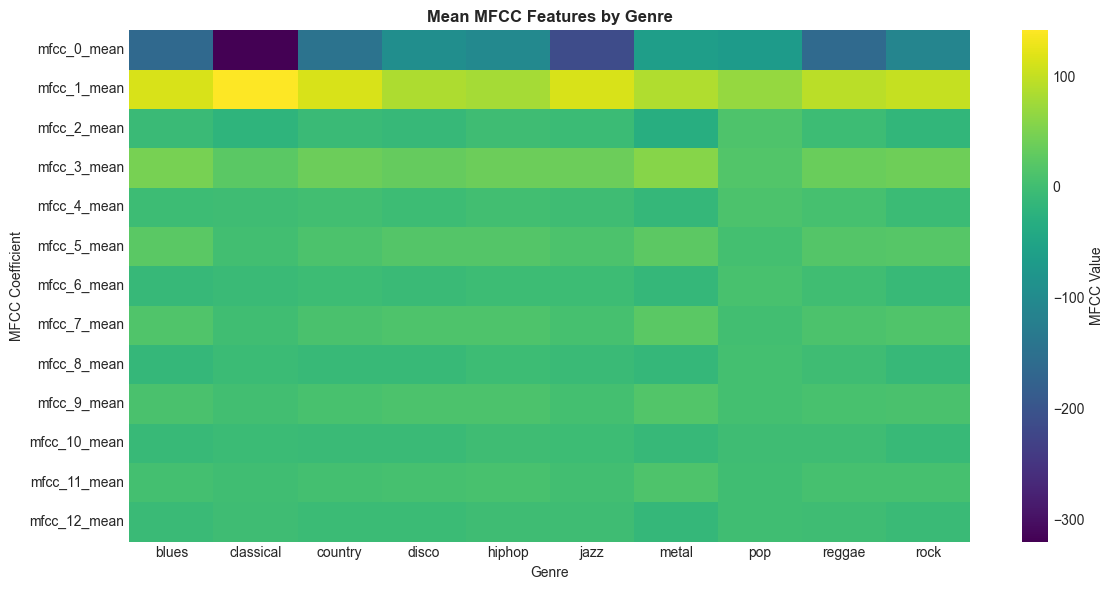

✓ Gambar 2: MFCC Heatmap


In [9]:
# 2. MFCC Heatmap by Genre
fig, ax = plt.subplots(figsize=(12, 6))

mfcc_mean_cols = [col for col in mfcc_df.columns if 'mean' in col]
mfcc_by_genre = mfcc_df.groupby('genre')[mfcc_mean_cols].mean()

sns.heatmap(mfcc_by_genre.T, cmap='viridis', ax=ax, cbar_kws={'label': 'MFCC Value'})
ax.set_title('Mean MFCC Features by Genre', fontsize=12, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('MFCC Coefficient')

plt.tight_layout()
plt.savefig('02_mfcc_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 2: MFCC Heatmap")

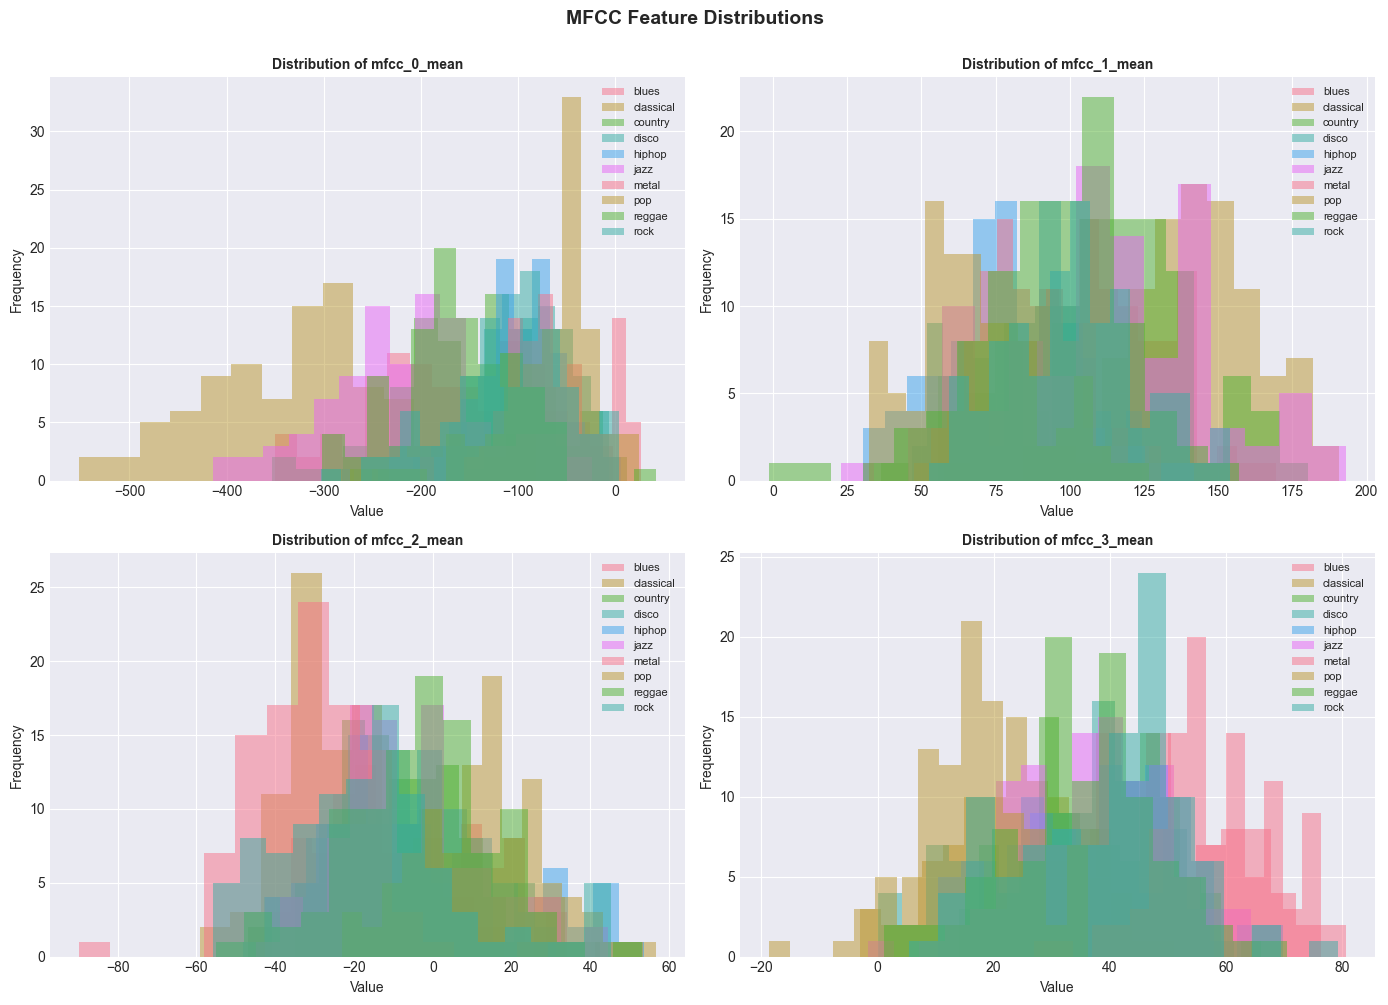

✓ Gambar 3: MFCC Distribution


In [10]:
# 3. MFCC Distribution by Genre
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

mfcc_features_to_plot = ['mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean']

for idx, feature in enumerate(mfcc_features_to_plot):
    ax = axes[idx // 2, idx % 2]
    for genre in mfcc_df['genre'].unique():
        genre_data = mfcc_df[mfcc_df['genre'] == genre][feature]
        ax.hist(genre_data, alpha=0.5, label=genre, bins=15)
    
    ax.set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('MFCC Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_mfcc_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 3: MFCC Distribution")

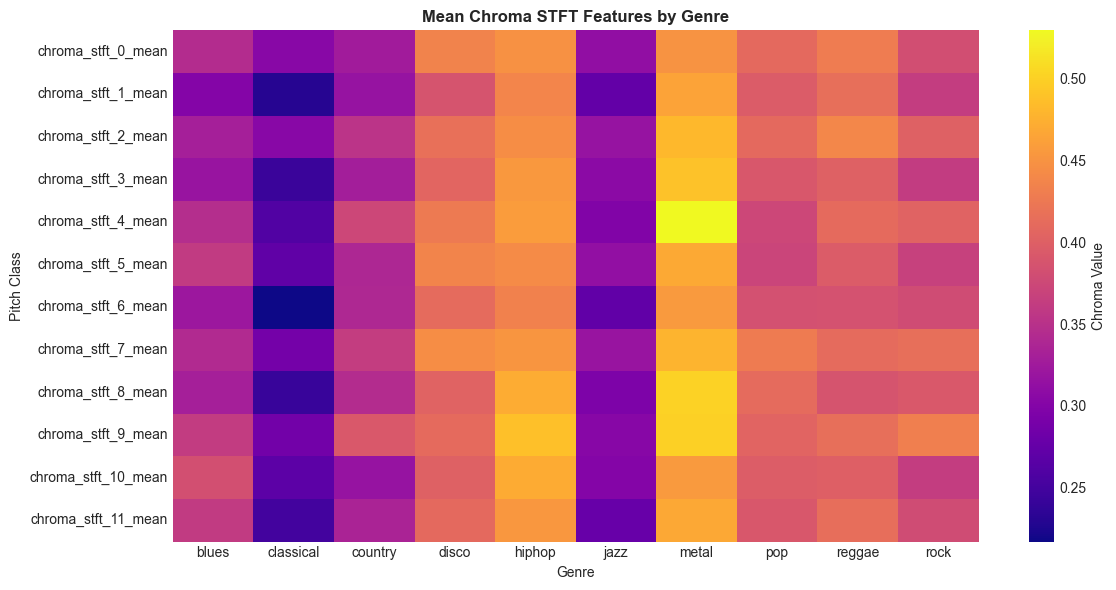

✓ Gambar 4: Chroma Heatmap


In [11]:
# 4. Chroma Features Heatmap
fig, ax = plt.subplots(figsize=(12, 6))

chroma_stft_mean_cols = [col for col in chroma_df.columns if 'chroma_stft' in col and 'mean' in col]
chroma_by_genre = chroma_df.groupby('genre')[chroma_stft_mean_cols].mean()

sns.heatmap(chroma_by_genre.T, cmap='plasma', ax=ax, cbar_kws={'label': 'Chroma Value'})
ax.set_title('Mean Chroma STFT Features by Genre', fontsize=12, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Pitch Class')

plt.tight_layout()
plt.savefig('04_chroma_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 4: Chroma Heatmap")

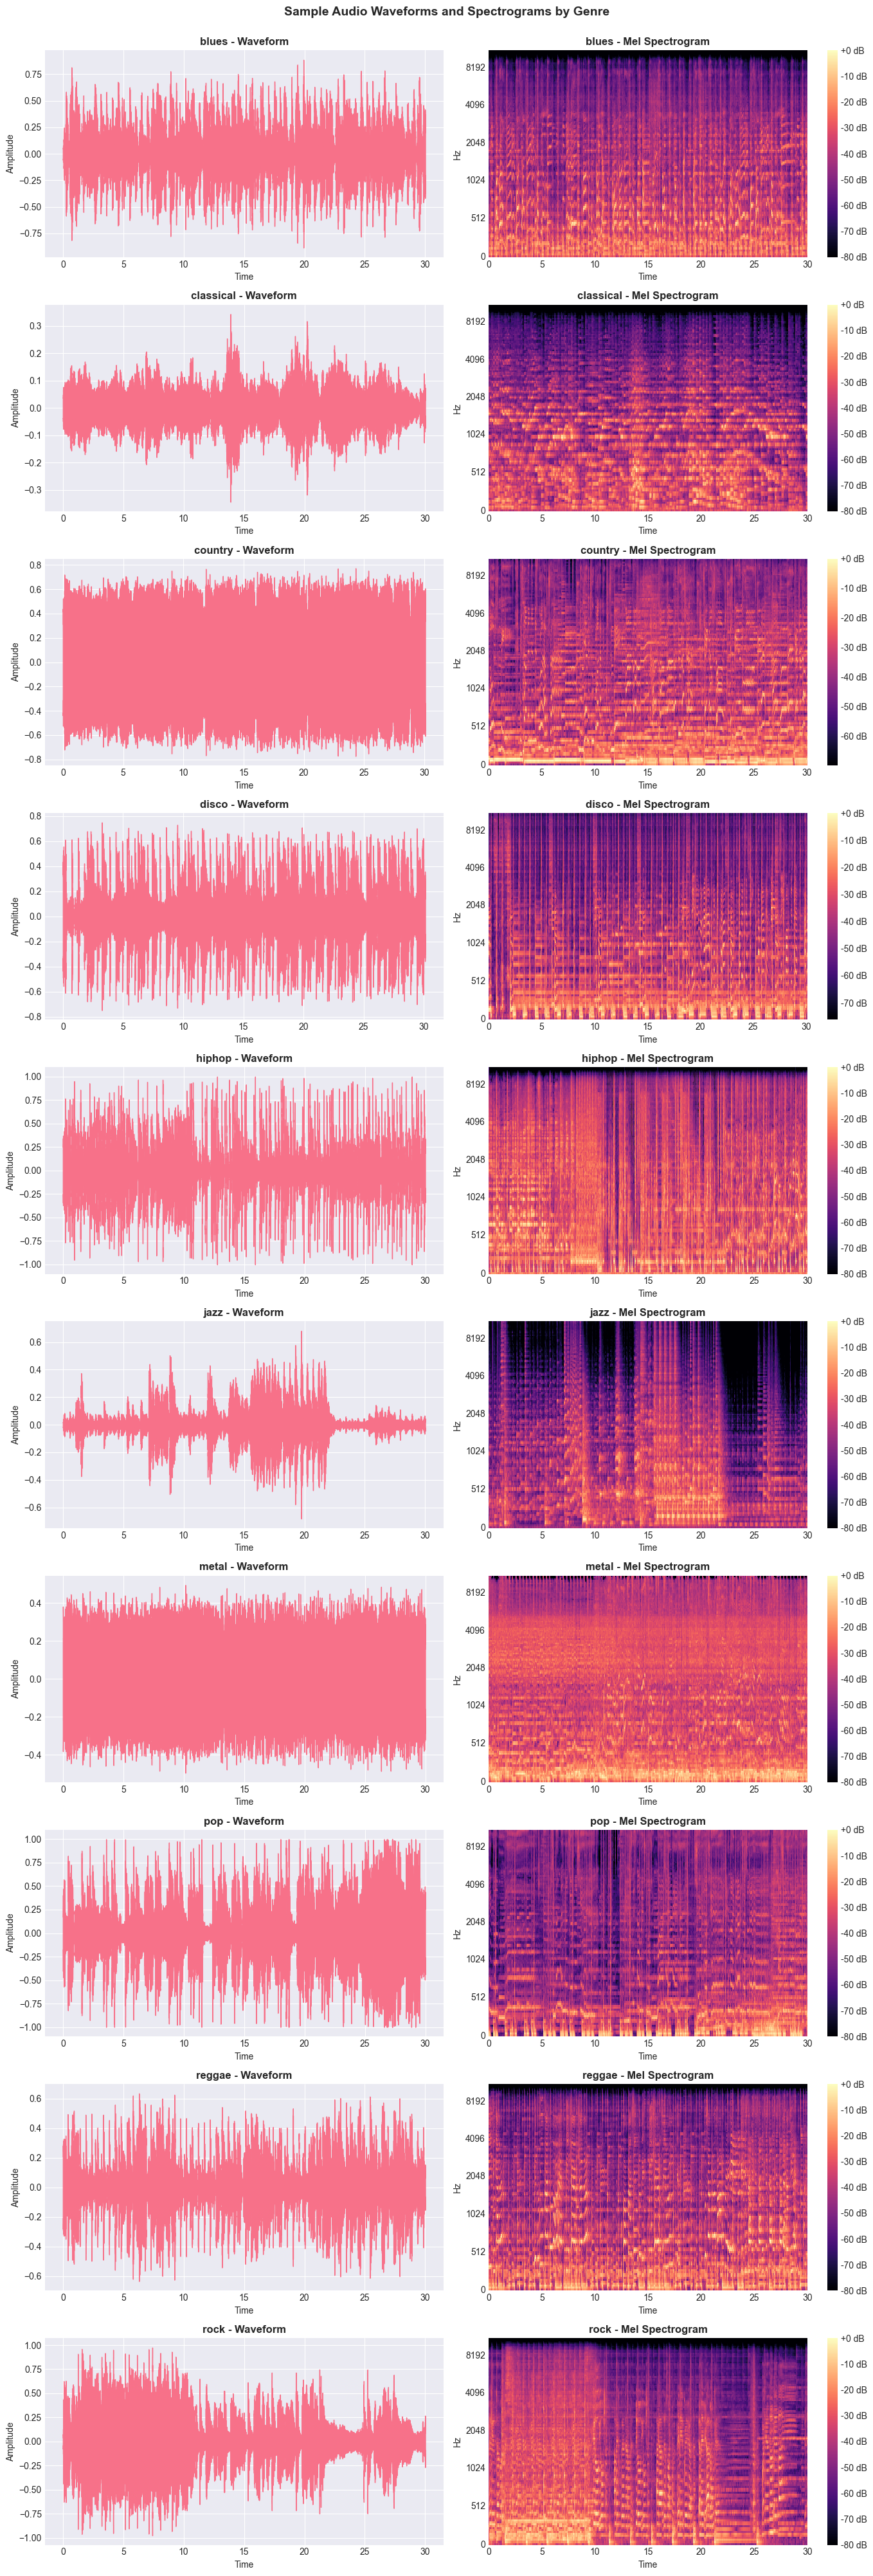

✓ Gambar 5: Waveform dan Spectrogram


In [12]:
# 5. Waveform dan Spectrogram untuk sample audio dari setiap genre
genres_list = sorted(set(genres))
fig, axes = plt.subplots(len(genres_list), 2, figsize=(14, 4*len(genres_list)))

for idx, genre in enumerate(genres_list):
    # Get first audio file from this genre
    genre_files = [f for f, g in zip(audio_files, genres) if g == genre]
    audio_file = genre_files[0]
    
    # Load audio
    y, sr = librosa.load(audio_file, sr=None)
    
    # Plot waveform
    ax = axes[idx, 0] if len(genres_list) > 1 else axes[0]
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(f'{genre} - Waveform', fontweight='bold')
    ax.set_ylabel('Amplitude')
    
    # Plot spectrogram
    ax = axes[idx, 1] if len(genres_list) > 1 else axes[1]
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'{genre} - Mel Spectrogram', fontweight='bold')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.suptitle('Sample Audio Waveforms and Spectrograms by Genre', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('05_waveform_spectrogram.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 5: Waveform dan Spectrogram")

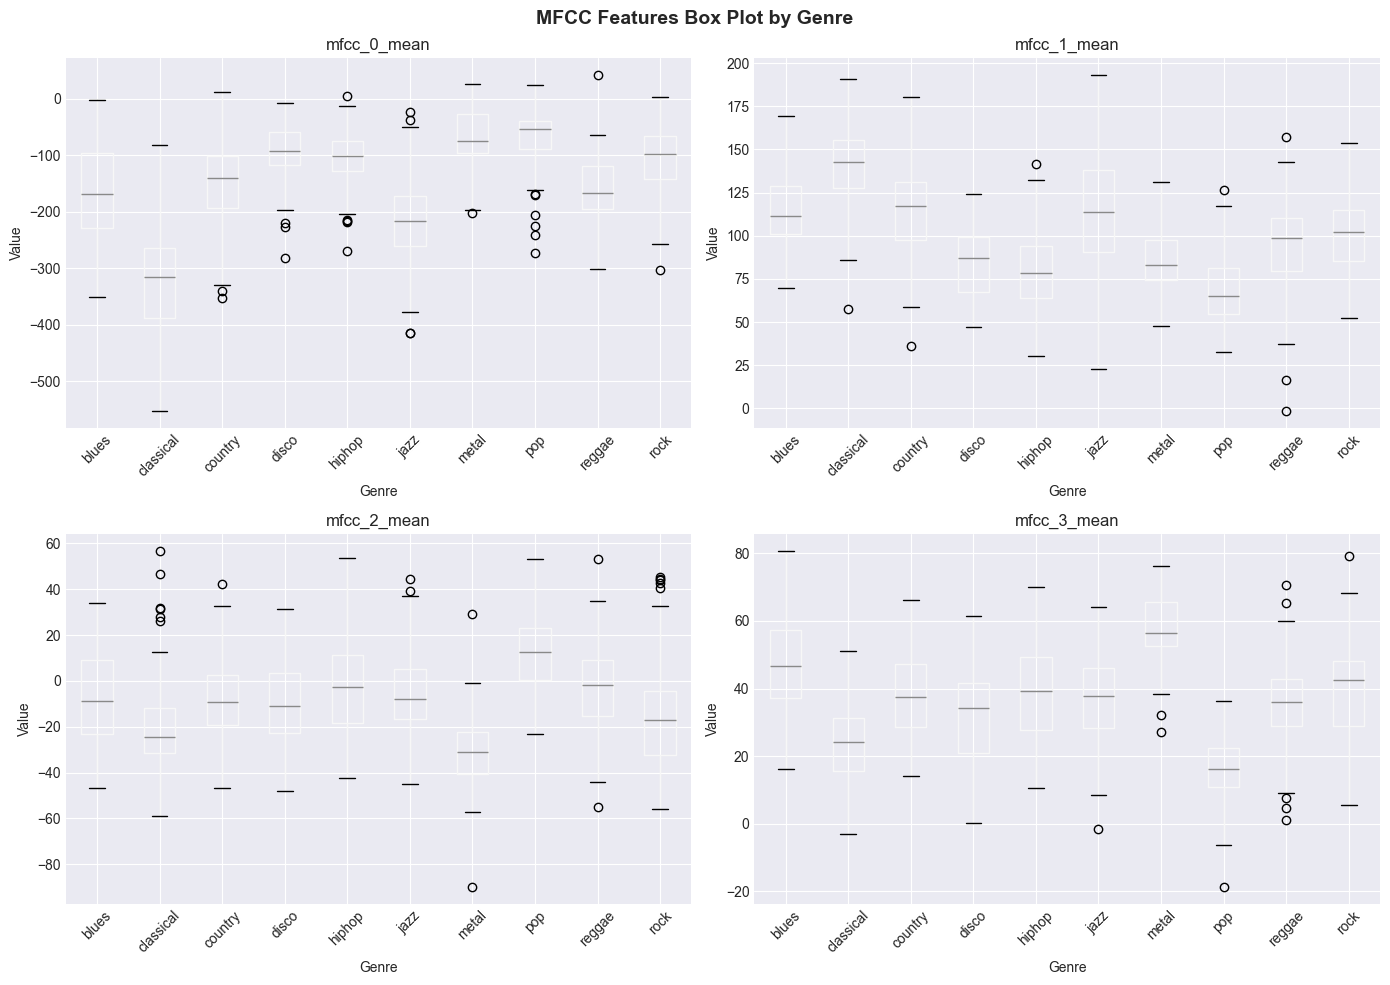

✓ Gambar 6: MFCC Box Plot


In [13]:
# 6. Box plot untuk MFCC features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

mfcc_features_to_plot = ['mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean']

for idx, feature in enumerate(mfcc_features_to_plot):
    ax = axes[idx // 2, idx % 2]
    mfcc_df.boxplot(column=feature, by='genre', ax=ax)
    ax.set_title(f'{feature}')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Value')
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.suptitle('MFCC Features Box Plot by Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_mfcc_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 6: MFCC Box Plot")

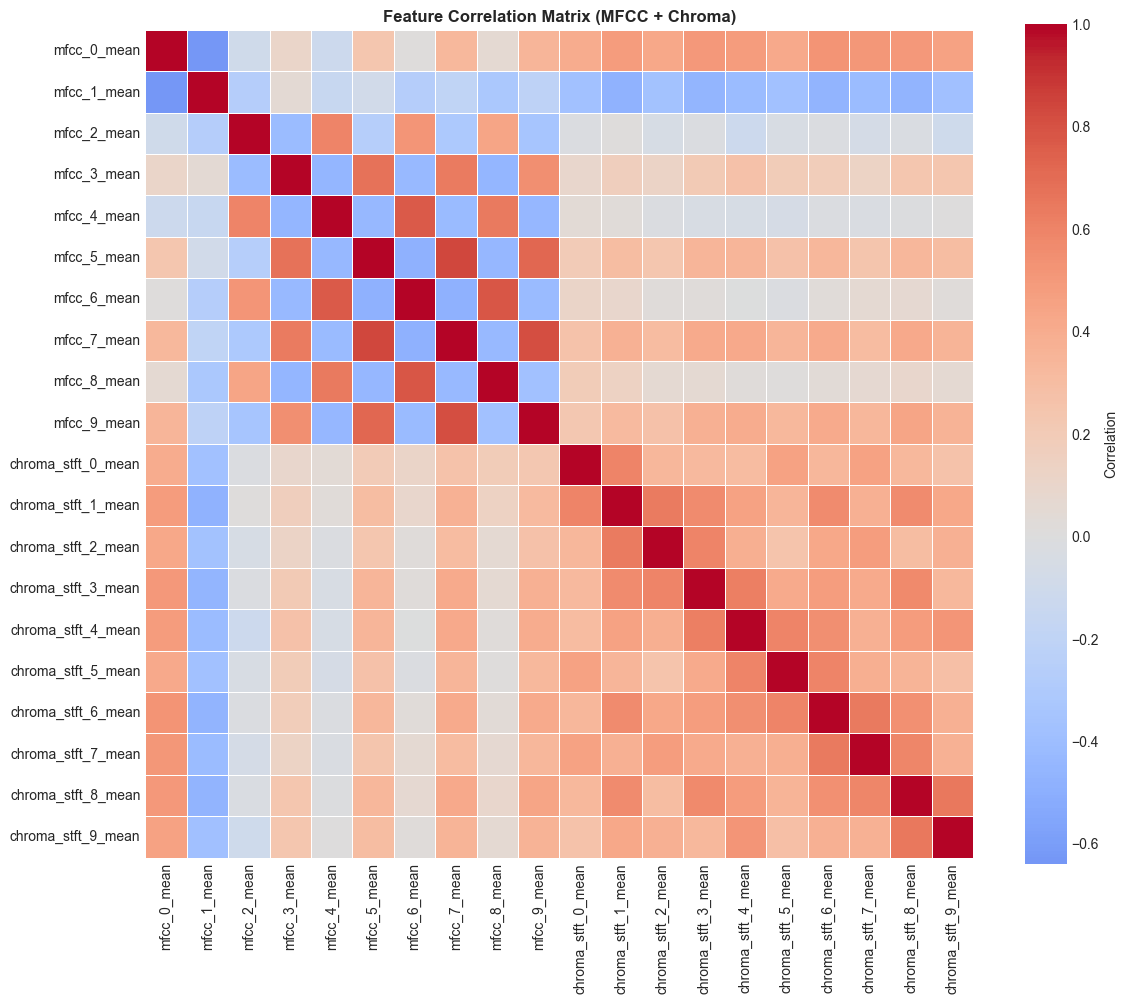

✓ Gambar 7: Correlation Heatmap


In [14]:
# 7. Feature Correlation Heatmap (sample of features)
fig, ax = plt.subplots(figsize=(12, 10))

# Select first 20 features untuk correlation heatmap
mfcc_mean_cols = [col for col in mfcc_df.columns if 'mean' in col][:10]
chroma_cols = [col for col in chroma_df.columns if 'chroma_stft' in col and 'mean' in col][:10]

selected_features = mfcc_mean_cols + chroma_cols
correlation_df = mfcc_df[mfcc_mean_cols].join(chroma_df[chroma_cols])
corr_matrix = correlation_df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', ax=ax, center=0, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix (MFCC + Chroma)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 7: Correlation Heatmap")

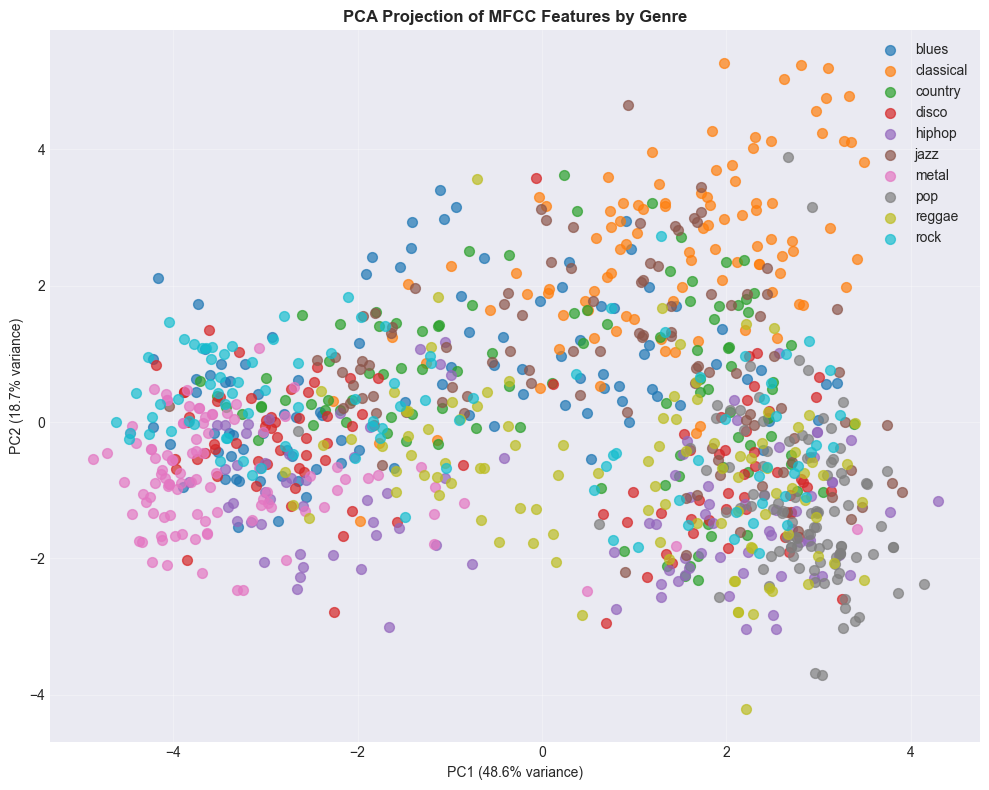

✓ Gambar 8: PCA Visualization
✓ Total variance explained by PC1 and PC2: 67.3%


In [15]:
# 8. PCA Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data for PCA
mfcc_mean_cols = [col for col in mfcc_df.columns if 'mean' in col]
X = mfcc_df[mfcc_mean_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'blues': '#1f77b4', 'classical': '#ff7f0e', 'country': '#2ca02c', 'disco': '#d62728', 
          'hiphop': '#9467bd', 'jazz': '#8c564b', 'metal': '#e377c2', 'pop': '#7f7f7f', 
          'reggae': '#bcbd22', 'rock': '#17becf'}

for genre in sorted(set(mfcc_df['genre'])):
    indices = mfcc_df['genre'] == genre
    ax.scatter(X_pca[indices, 0], X_pca[indices, 1], label=genre, alpha=0.7, s=50, color=colors.get(genre, None))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Projection of MFCC Features by Genre', fontweight='bold', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_pca_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Gambar 8: PCA Visualization")
print(f"✓ Total variance explained by PC1 and PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}")

## 8. Save Extracted Features

In [16]:
# Save extracted features to CSV files
print("Saving extracted features...")

# Save MFCC features
mfcc_df.to_csv('extracted_features_mfcc.csv', index=False)
print(f"✓ MFCC features saved: extracted_features_mfcc.csv ({mfcc_df.shape})")

# Save Mel Spectrogram features
mel_spec_df.to_csv('extracted_features_mel_spectrogram.csv', index=False)
print(f"✓ Mel Spectrogram features saved: extracted_features_mel_spectrogram.csv ({mel_spec_df.shape})")

# Save Chroma features
chroma_df.to_csv('extracted_features_chroma.csv', index=False)
print(f"✓ Chroma features saved: extracted_features_chroma.csv ({chroma_df.shape})")

# Save combined features
combined_df.to_csv('extracted_features_combined.csv', index=False)
print(f"✓ Combined features saved: extracted_features_combined.csv ({combined_df.shape})")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Total audio files processed: {len(audio_files)}")
print(f"Total genres: {len(set(genres))}")
print(f"\nFeatures extracted:")
print(f"  - MFCC: {len(mfcc_columns)} features per file")
print(f"  - Mel Spectrogram: {len(mel_columns)} features per file")
print(f"  - Chroma: {len(chroma_columns)} features per file")
print(f"  - Total combined: {combined_df.shape[1] - 2} features per file")
print(f"\nOutput files:")
print(f"  - extracted_features_mfcc.csv")
print(f"  - extracted_features_mel_spectrogram.csv")
print(f"  - extracted_features_chroma.csv")
print(f"  - extracted_features_combined.csv")
print("\n✓ EDA selesai!")

Saving extracted features...
✓ MFCC features saved: extracted_features_mfcc.csv ((999, 28))
✓ Mel Spectrogram features saved: extracted_features_mel_spectrogram.csv ((999, 513))
✓ Chroma features saved: extracted_features_chroma.csv ((999, 73))
✓ Combined features saved: extracted_features_combined.csv ((999, 612))

SUMMARY
Total audio files processed: 1000
Total genres: 10

Features extracted:
  - MFCC: 26 features per file
  - Mel Spectrogram: 512 features per file
  - Chroma: 72 features per file
  - Total combined: 610 features per file

Output files:
  - extracted_features_mfcc.csv
  - extracted_features_mel_spectrogram.csv
  - extracted_features_chroma.csv
  - extracted_features_combined.csv

✓ EDA selesai!
